# Pre_Thk_VM 단계별 동작 분석

**`algorithm_new/Common/PRE_THK_VM.py`** 의 실제 함수들을 그대로 호출하면서,  
각 단계에서 어떤 계산이 이루어지는지 트렌드로 확인합니다.

```
전체 흐름
────────────────────────────────────────────────────────────
 merge_df (CMP 실측)
   │
   ├─ [준비]  BIAS 계산  (CMP 후 두께 편차, 0-centering)
   │
   ├─ [Step 1] compute_detrend()          ← PRE_THK_VM_Get
   │     ├─ Pol_Time, RR 계산
   │     ├─ FIX_Time 기준 Unctr_Thk
   │     ├─ pad_cycle 분리
   │     ├─ 사이클별 Rolling MA
   │     └─ Detrend_Thk = Unctr_Thk - MA
   │
   ├─ [Step 2] iqr_filter()               ← PRE_THK_VM_Get
   │     └─ Detrend_Thk 이상치 제거
   │
   ├─ [Step 3] rolling_mean()             ← PRE_THK_VM_Get
   │     └─ pre_eq_ch별 시간 윈도우 이동 평균 → Pre_Thk
   │
   └─ [Step 4] _extract_latest()          ← Common.Module
         └─ pre_eq_ch별 최신값 1건 추출 → 최종 학습값
────────────────────────────────────────────────────────────
```

---
## 환경 설정

In [1]:
import sys, os
from pathlib import Path
from unittest.mock import MagicMock

ALGO_DIR = Path('..') / 'algorithm_new'
sys.path.insert(0, str(ALGO_DIR))

# Jupyter async 환경에서 Django ORM 허용
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = '1'

# MongoDB Mock (로컬 환경 전용)
import pymongo as _pymongo
_cli = MagicMock()
_cli.__getitem__.return_value = MagicMock()
_cli.close.return_value = None
_pymongo.MongoClient = MagicMock(return_value=_cli)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

try:
    matplotlib.rc('font', family='AppleGothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## 데이터 & 파라미터 로드
Django DB에서 Set-up 정보를 읽고, CMP 실측 데이터(CSV)를 로드합니다.

In [2]:
from Common.Get_Data import Get_data
from Common.PRE_THK_VM import PRE_THK_VM_Get   # 실제 모듈 임포트
from Common.Module import _extract_latest       # 최신값 추출 헬퍼

# ── Set-up 정보 (Django DB) ─────────────────────────────────────────
mico = Get_data.baseinfoGetData(Family='DRAM', oper_desc='M1 CU CMP')
mico['Group_Name'] = mico['Group_Name'].fillna('not_group')

# ── 파라미터 추출 ────────────────────────────────────────────────────
APC_Para       = mico['APC_Para'].iloc[0]                           # 'P3'
Thk_Para       = mico['Thk_Para'].iloc[0]                           # 'AMAT_POST_OCD_AVG'
Pre_Target     = float(mico['Pre_Target'].iloc[0])                  # CMP 투입 전 목표 두께
Post_Target    = float(mico['Target'].iloc[0])                      # CMP 후 목표 두께
Thk_Para_13P   = mico[mico['FB_Type']=='TIME']['Thk_Para'].iloc[0]  # TIME 기준 두께 파라미터
Target_13P     = float(mico[mico['FB_Type']=='TIME']['Target'].iloc[0])
Pre_Thk_Period = str(mico['Pre_Thk_Period'].iloc[0]) + 'D'          # '3D'
Pad_Para       = Get_data.PadParaGet(APC_Para)                      # 'AMAT_PAD_3'
APC_Para_merge = Get_data.APCParaGet(APC_Para, pol_type=3)          # ['P3']

print('── Set-up 파라미터 ──────────────────────────────')
print(f'  APC_Para      : {APC_Para}')
print(f'  Thk_Para      : {Thk_Para}')
print(f'  Pre_Target    : {Pre_Target} Å  (CMP 투입 전 목표)')
print(f'  Post_Target   : {Post_Target} Å  (CMP 후 목표)')
print(f'  Pad_Para      : {Pad_Para}')
print(f'  Pre_Thk_Period: {Pre_Thk_Period}')

# ── CMP 실측 데이터 로드 ─────────────────────────────────────────────
merge_df = pd.read_csv(
    ALGO_DIR / 'merge_df_sample.csv',
    parse_dates=['Date', 'pre_oper_time']
)
merge_df['IDLE'] = merge_df['IDLE'].fillna('')
print(f'\nmerge_df: {merge_df.shape[0]:,}행  |  '
      f'기간: {merge_df["Date"].min().date()} ~ {merge_df["Date"].max().date()}')

── Set-up 파라미터 ──────────────────────────────
  APC_Para      : P3
  Thk_Para      : AMAT_POST_OCD_AVG
  Pre_Target    : 2350.0 Å  (CMP 투입 전 목표)
  Post_Target   : 1900.0 Å  (CMP 후 목표)
  Pad_Para      : AMAT_PAD_3
  Pre_Thk_Period: 3D

merge_df: 20,844행  |  기간: 2026-04-15 ~ 2026-05-15


---
## 준비 — BIAS 계산

**BIAS** = 두 레시피(13P ↔ 기타) 간 두께 편차를 제거한 0-centering 값입니다.  
`compute_detrend` 는 이 BIAS 컬럼을 이미 계산된 상태로 받습니다.

```python
# Module.py 의 compute_pre_thk_vm 내부 코드 (non-ITM 경로)
merge_df['BIAS'] = (merge_df[Thk_Para] - merge_df[Thk_Para_13P]) - (Post_Target - Target_13P)
```

> DRAM M1 CU CMP 의 경우 `Thk_Para == Thk_Para_13P`(동일 파라미터, 레시피만 다름)이므로  
> BIAS = 두께 - 목표 오프셋 으로 단순화됩니다.

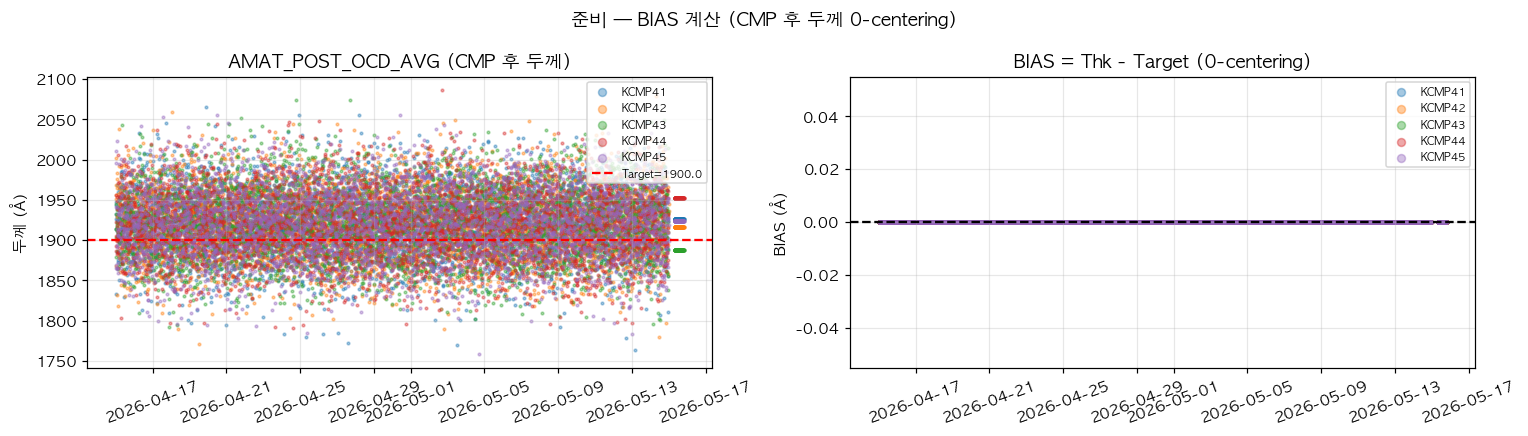

BIAS 평균: 0.00 Å  |  표준편차: 0.00 Å


In [3]:
# ── 실제 Module.py compute_pre_thk_vm 내부 코드와 동일 ────────────────
merge_df['BIAS'] = (
    merge_df[Thk_Para] - merge_df[Thk_Para_13P]
) - (Post_Target - Target_13P)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('준비 — BIAS 계산 (CMP 후 두께 0-centering)', fontsize=12, fontweight='bold')

colors = plt.cm.tab10.colors

# ① Thk_Para 원본 트렌드
ax = axes[0]
for i, eqp in enumerate(sorted(merge_df['eqp_id'].unique())):
    sub = merge_df[merge_df['eqp_id'] == eqp].sort_values('Date')
    ax.scatter(sub['Date'], sub[Thk_Para], s=3, alpha=0.4,
               color=colors[i % len(colors)], label=eqp)
ax.axhline(Post_Target, color='red', linewidth=1.5, linestyle='--', label=f'Target={Post_Target}')
ax.set_title(f'{Thk_Para} (CMP 후 두께)')
ax.set_ylabel('두께 (Å)')
ax.legend(markerscale=3, fontsize=7)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)

# ② BIAS 트렌드
ax = axes[1]
for i, eqp in enumerate(sorted(merge_df['eqp_id'].unique())):
    sub = merge_df[merge_df['eqp_id'] == eqp].sort_values('Date')
    ax.scatter(sub['Date'], sub['BIAS'], s=3, alpha=0.4,
               color=colors[i % len(colors)], label=eqp)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('BIAS = Thk - Target (0-centering)')
ax.set_ylabel('BIAS (Å)')
ax.legend(markerscale=3, fontsize=7)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print(f'BIAS 평균: {merge_df["BIAS"].mean():.2f} Å  |  표준편차: {merge_df["BIAS"].std():.2f} Å')

---
## Step 1 — `compute_detrend()` : Unctr_Thk → Detrend_Thk

```python
# PRE_THK_VM.py  compute_detrend() 핵심 로직
temp_df['Pol_Time']  = temp_df[APC_Para_merge].sum(axis=1)     # 총 연마 시간
temp_df['RR']        = (Pre_Target - Thk) / Pol_Time           # 실측 Removal Rate

FIX_Time = temp_df['Pol_Time'].mean()                          # 전체 평균 연마 시간

for eq_rcp in unique(eqp_id + recipe_id):
    Unctr_Thk  = Pre_Target - (RR * FIX_Time)                  # 고정 시간 기준 두께 역산
    pad_cycle  = (Pad_Para.diff() < -0.5).cumsum() + 1         # 패드 교체 기준 구간 번호

    for cycle in pad_cycle:
        Unctr_Thk_MA = Unctr_Thk.rolling(window=10).mean()     # 패드 사이클별 MA

    Detrend_Thk = Unctr_Thk - Unctr_Thk_MA                    # 추세 제거 → 0-centering
```

In [4]:
# ── PRE_THK_VM_Get.compute_detrend() 실제 함수 호출 ─────────────────
pre_thk_df = PRE_THK_VM_Get.compute_detrend(
    merge_df,
    APC_Para_merge,
    Thk_Para,
    Pre_Target,
    Post_Target,
    Pad_Para,
    use_pressure=False
)

print('compute_detrend 반환 컬럼:')
print(f'  {pre_thk_df.columns.tolist()}')
print(f'\n총 {len(pre_thk_df):,}행  |  장비×레시피 조합: {pre_thk_df.groupby(["eqp_id","recipe_id"]).ngroups}개')
print(f'pad_cycle 값: {sorted(pre_thk_df["pad_cycle"].unique())}')
print(f'Detrend_Thk NaN: {pre_thk_df["Detrend_Thk"].isna().sum()}건 (MA 미산출 초반 행)')
pre_thk_df[['Date','eqp_id','recipe_id','AMAT_PAD_3','P3','Pol_Time','RR','Unctr_Thk','pad_cycle','Unctr_Thk_MA','Detrend_Thk']].head(8)

compute_detrend 반환 컬럼:
  ['Date', 'process_id', 'recipe_id', 'eqp_id', 'operation_id', 'lot_id', 'substrate_id', 'pre_eqp_id', 'pre_eqp_ch', 'pre_oper_time', 'AMAT_POST_OCD_AVG', 'AMAT_PAD_3', 'BIAS', 'P3', 'Pol_Time', 'RR', 'Unctr_Thk', 'pad_cycle', 'Unctr_Thk_MA', 'Detrend_Thk']

총 19,496행  |  장비×레시피 조합: 20개
pad_cycle 값: [1, 2, 3, 4, 5]
Detrend_Thk NaN: 639건 (MA 미산출 초반 행)


,Date,eqp_id,recipe_id,AMAT_PAD_3,P3,Pol_Time,RR,Unctr_Thk,pad_cycle,Unctr_Thk_MA,Detrend_Thk
0,2026-04-15 02:23:21,KCMP45,E2_M1CU_R12_TSV.CAS,0.2167,30.649,30.649,14.315420,2022.812637,1,NaN,NaN
1,2026-04-15 03:06:16,KCMP45,E2_M1CU_R12_TSV.CAS,0.2694,22.261,22.261,22.028089,1846.535021,1,NaN,NaN
2,2026-04-15 03:38:37,KCMP45,E2_M1CU_R12_TSV.CAS,0.3211,24.414,24.414,19.325809,1908.297237,1,NaN,NaN
3,2026-04-15 03:49:11,KCMP45,E2_M1CU_R12_TSV.CAS,0.3313,17.484,17.484,23.502562,1812.835074,1,NaN,NaN
4,2026-04-15 04:21:48,KCMP45,E2_M1CU_R12_TSV.CAS,0.3894,13.621,13.621,31.999728,1618.627333,1,NaN,NaN
5,2026-04-15 04:53:08,KCMP45,E2_M1CU_R12_TSV.CAS,0.4395,28.690,28.690,16.159930,1980.655261,1,NaN,NaN
6,2026-04-15 05:15:26,KCMP45,E2_M1CU_R12_TSV.CAS,0.4663,23.932,23.932,18.679107,1923.077981,1,NaN,NaN
7,2026-04-15 05:58:51,KCMP45,E2_M1CU_R12_TSV.CAS,0.5338,23.599,23.599,16.252549,1978.538410,1,NaN,NaN


### 1-1. Pol_Time & RR
각 웨이퍼의 실제 연마 시간(`Pol_Time`)과 그로 계산된 실측 연마율(`RR`)입니다.

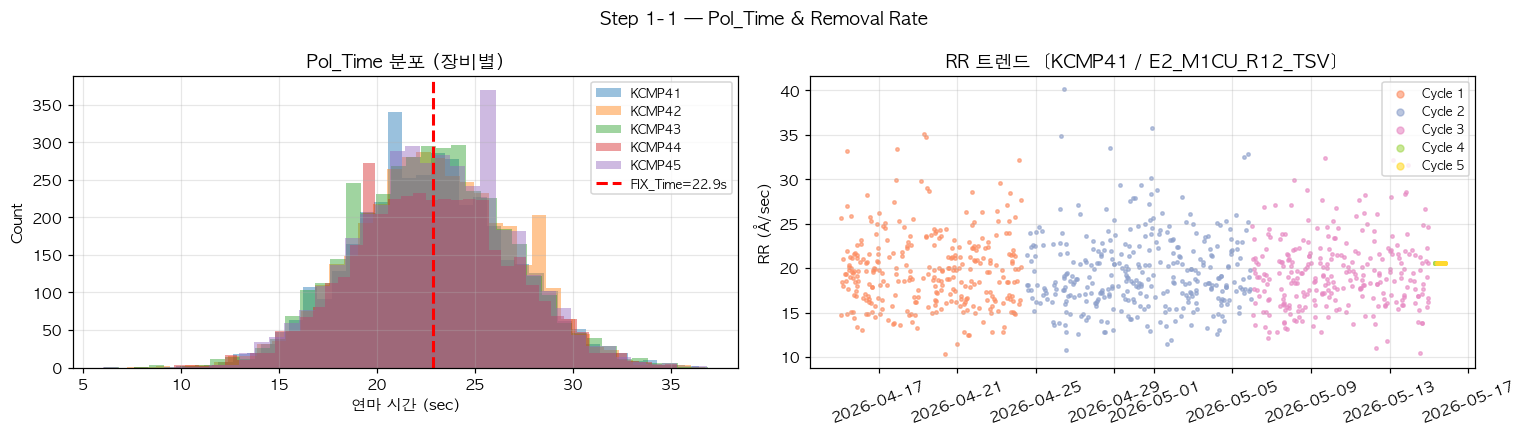

FIX_Time (전체 평균 연마 시간) = 22.86 sec


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Step 1-1 — Pol_Time & Removal Rate', fontsize=12, fontweight='bold')

# FIX_Time: compute_detrend 내부에서 계산하는 전체 평균 연마 시간
FIX_Time = pre_thk_df['Pol_Time'].mean()

# ① Pol_Time 분포 (장비별)
ax = axes[0]
for i, eqp in enumerate(sorted(pre_thk_df['eqp_id'].unique())):
    sub = pre_thk_df[pre_thk_df['eqp_id'] == eqp]
    ax.hist(sub['Pol_Time'], bins=40, alpha=0.45, color=colors[i], label=eqp)
ax.axvline(FIX_Time, color='red', linewidth=2, linestyle='--', label=f'FIX_Time={FIX_Time:.1f}s')
ax.set_title('Pol_Time 분포 (장비별)')
ax.set_xlabel('연마 시간 (sec)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ② RR 트렌드 (KCMP41 / R12_TSV — 대표 1개)
ax = axes[1]
DEMO_EQP = 'KCMP41'; DEMO_RCP = 'E2_M1CU_R12_TSV.CAS'
demo = pre_thk_df[(pre_thk_df['eqp_id']==DEMO_EQP) & (pre_thk_df['recipe_id']==DEMO_RCP)].sort_values('Date')
cycle_colors = plt.cm.Set2.colors
for cyc in sorted(demo['pad_cycle'].unique()):
    c = demo[demo['pad_cycle']==cyc]
    ax.scatter(c['Date'], c['RR'], s=5, alpha=0.6,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'Cycle {cyc}')
ax.set_title(f'RR 트렌드  [{DEMO_EQP} / {DEMO_RCP.split(".")[0]}]')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print(f'FIX_Time (전체 평균 연마 시간) = {FIX_Time:.2f} sec')

### 1-2. Uncontrolled Thickness

```
Unctr_Thk = Pre_Target - (RR × FIX_Time)
```

실제 연마 시간 대신 **전체 평균 연마 시간(FIX_Time)** 을 적용했을 때 나올 두께를 역산합니다.  
이 값의 **추세(MA)** 가 바로 전공정 두께 편차의 드리프트입니다.

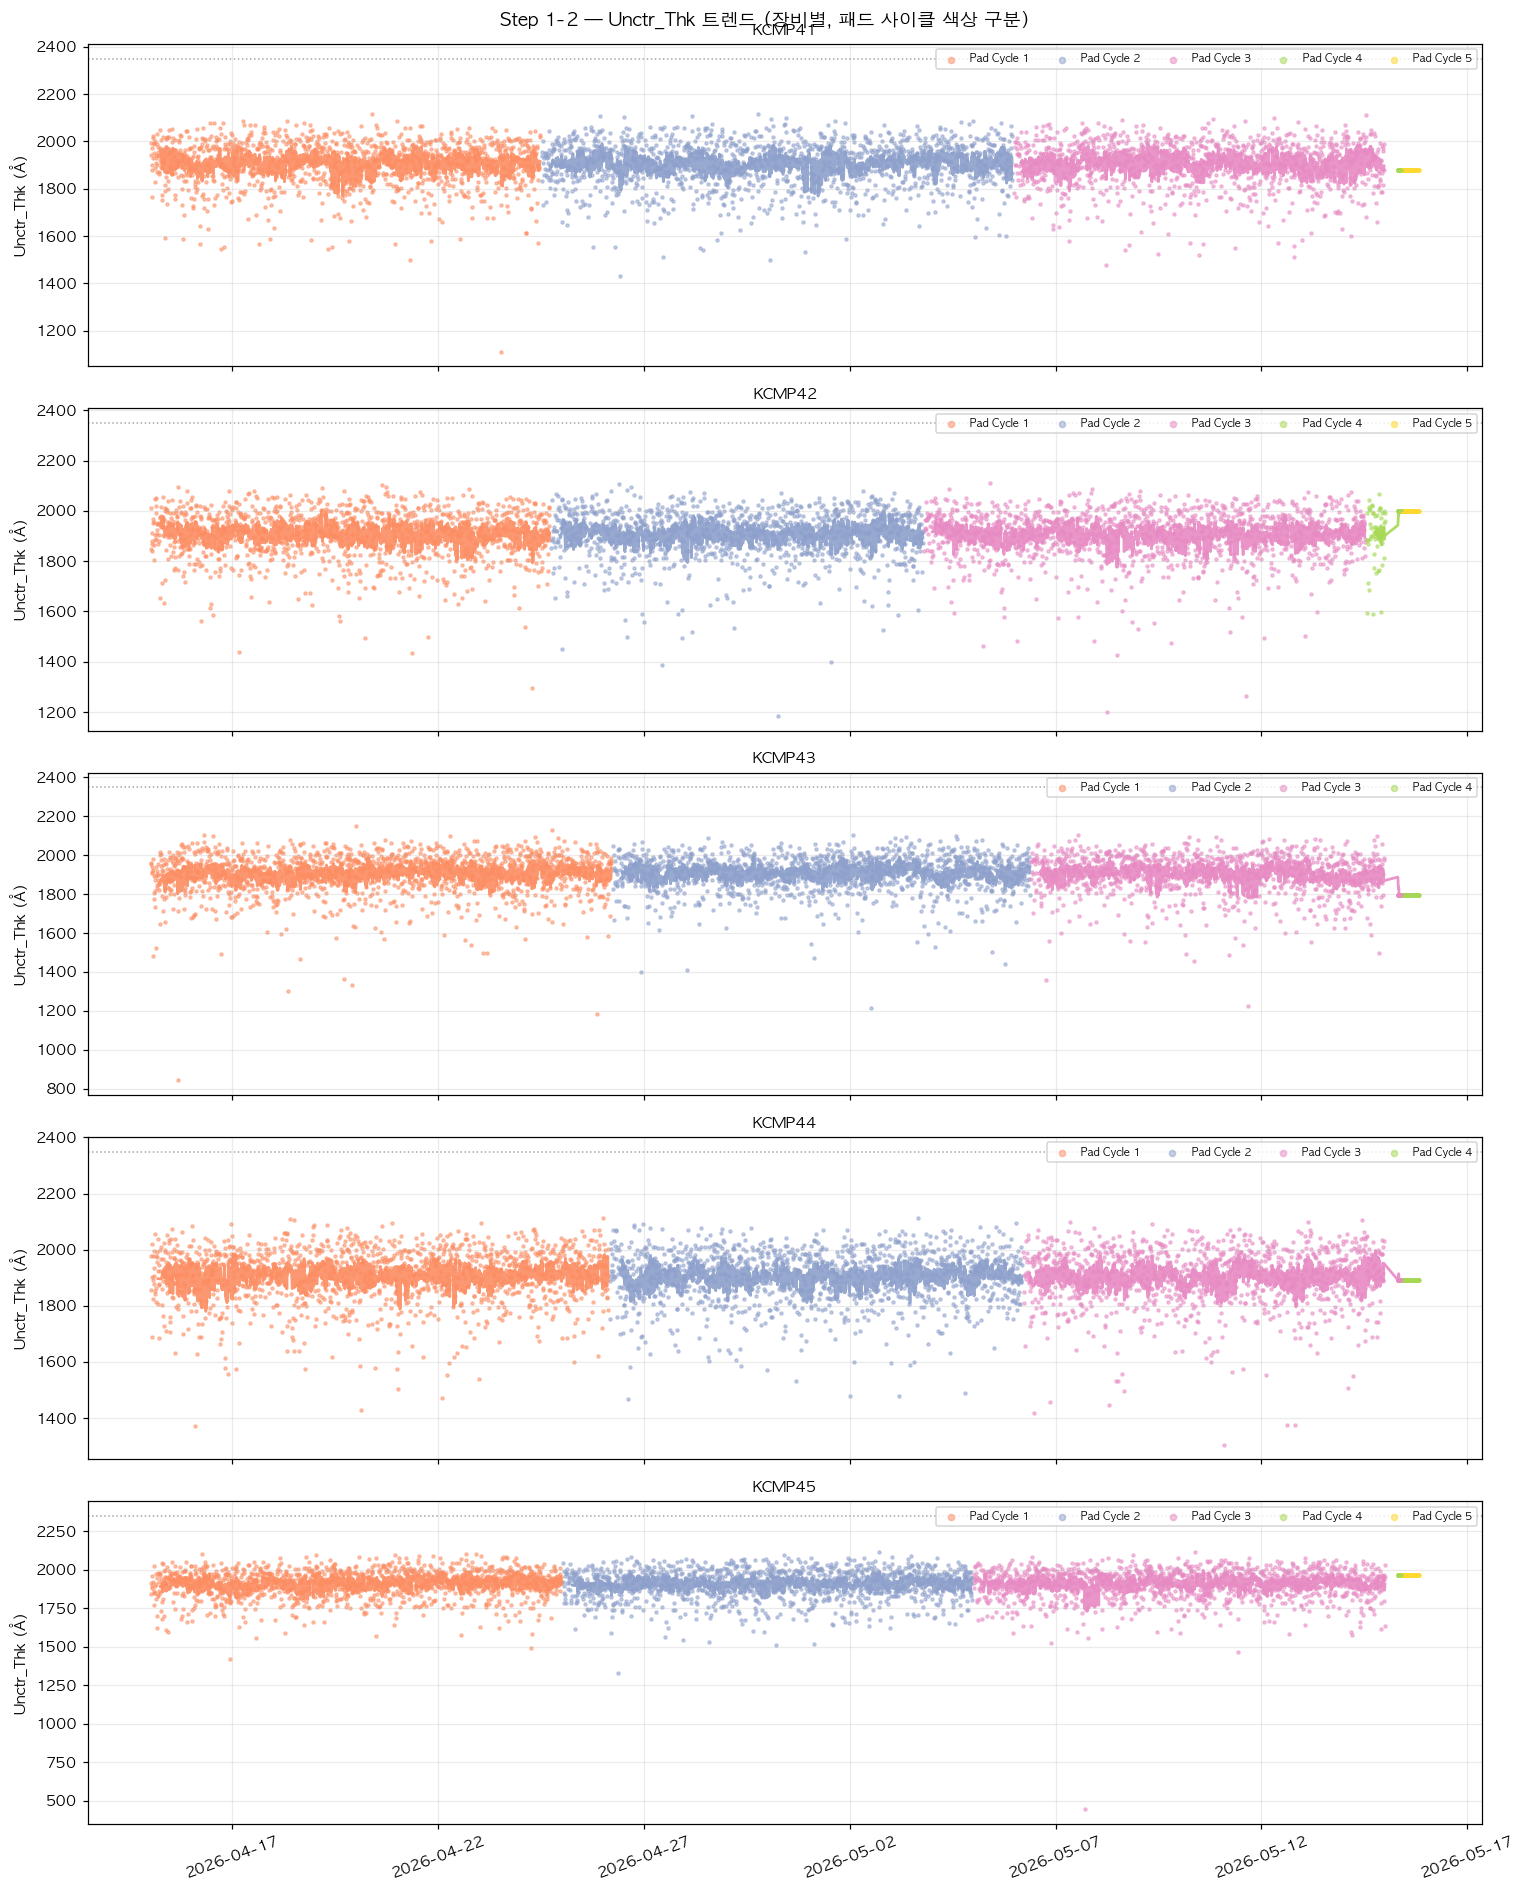

In [6]:
# ── 전체 장비 Unctr_Thk 트렌드 ──────────────────────────────────────
eqp_list = sorted(pre_thk_df['eqp_id'].unique())
n_eqp = len(eqp_list)

fig, axes = plt.subplots(n_eqp, 1, figsize=(14, 3.5 * n_eqp), sharex=True)
fig.suptitle('Step 1-2 — Unctr_Thk 트렌드 (장비별, 패드 사이클 색상 구분)', fontsize=12, fontweight='bold')

for ax, eqp in zip(axes, eqp_list):
    sub = pre_thk_df[pre_thk_df['eqp_id'] == eqp].sort_values('Date')

    for cyc in sorted(sub['pad_cycle'].unique()):
        c = sub[sub['pad_cycle'] == cyc]
        ax.scatter(c['Date'], c['Unctr_Thk'], s=4, alpha=0.5,
                   color=cycle_colors[cyc % len(cycle_colors)], label=f'Pad Cycle {cyc}')
        # MA 라인
        c_valid = c.dropna(subset=['Unctr_Thk_MA'])
        if len(c_valid) > 1:
            ax.plot(c_valid['Date'], c_valid['Unctr_Thk_MA'],
                    color=cycle_colors[cyc % len(cycle_colors)],
                    linewidth=1.8, alpha=0.9)

    ax.axhline(Pre_Target, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(f'{eqp}', fontsize=10)
    ax.set_ylabel('Unctr_Thk (Å)')
    ax.legend(fontsize=7, loc='upper right', ncol=5, markerscale=2)
    ax.grid(alpha=0.25)

axes[-1].tick_params(axis='x', rotation=20)
axes[-1].xaxis.set_major_locator(ticker.MaxNLocator(8))
plt.tight_layout()
plt.show()

### 1-3. 패드 사이클 분리 상세 (대표 장비)

```python
# PRE_THK_VM.py 내부
temp_df2['pad_cycle'] = (temp_df2[Pad_Para].diff() < -0.5).cumsum() + 1
```

패드 소모량(`AMAT_PAD_3`)이 이전 행보다 **0.5 이상 급감** 하면 패드가 교체된 것으로 판단합니다.

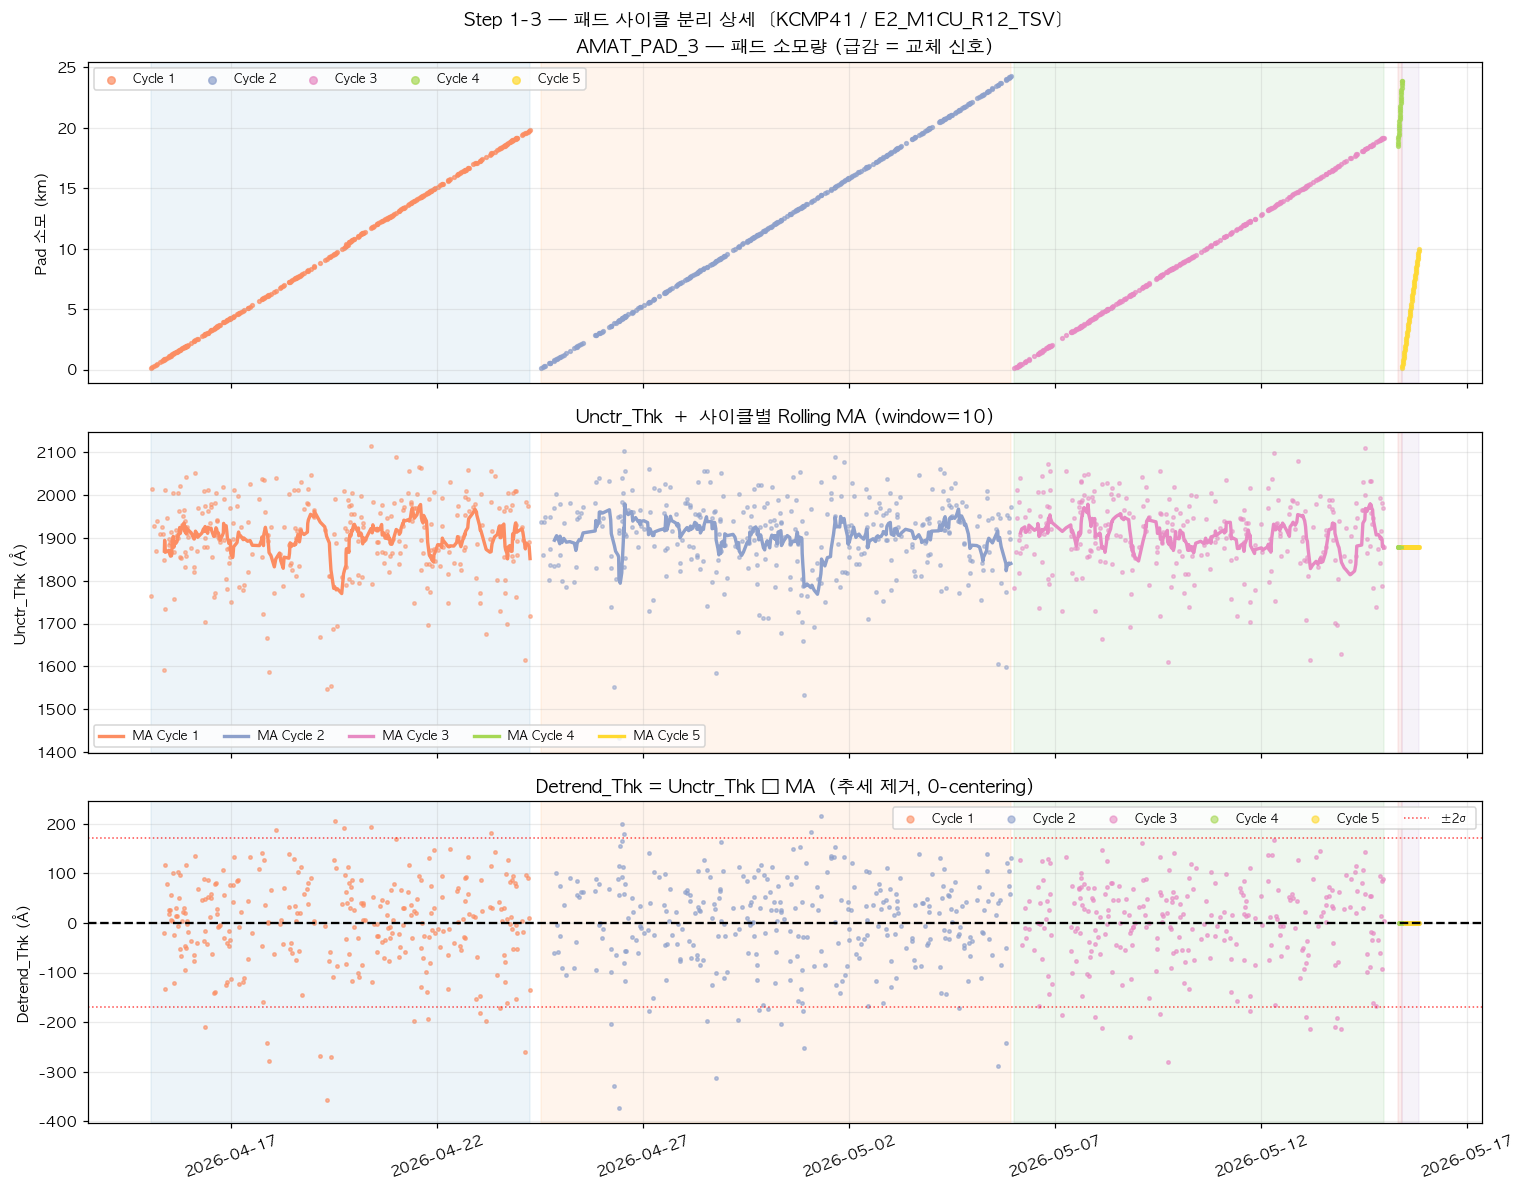

Detrend_Thk 통계 (KCMP41/E2_M1CU_R12_TSV)
  평균: -0.03 Å  (≈ 0 이어야 정상)
  표준편차: 85.17 Å


In [7]:
demo = pre_thk_df[
    (pre_thk_df['eqp_id'] == DEMO_EQP) &
    (pre_thk_df['recipe_id'] == DEMO_RCP)
].sort_values('Date').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    f'Step 1-3 — 패드 사이클 분리 상세  [{DEMO_EQP} / {DEMO_RCP.split(".")[0]}]',
    fontsize=12, fontweight='bold'
)

# ── 사이클 배경색 그리기 ──────────────────────────────────────────────
bg_alpha = 0.08
cycle_bg = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
cycle_boundaries = demo.groupby('pad_cycle')['Date'].agg(['min','max'])

for ax in axes:
    for cyc, row in cycle_boundaries.iterrows():
        ax.axvspan(row['min'], row['max'],
                   color=cycle_bg[(cyc - 1) % len(cycle_bg)], alpha=bg_alpha)

# ① 패드 소모량 — 사이클 경계 확인
ax = axes[0]
for cyc in sorted(demo['pad_cycle'].unique()):
    c = demo[demo['pad_cycle'] == cyc]
    ax.scatter(c['Date'], c[Pad_Para], s=6, alpha=0.7,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'Cycle {cyc}')
ax.set_title(f'{Pad_Para} — 패드 소모량 (급감 = 교체 신호)')
ax.set_ylabel('Pad 소모 (km)')
ax.legend(fontsize=8, markerscale=2, ncol=5)
ax.grid(alpha=0.25)

# ② Unctr_Thk + MA 라인
ax = axes[1]
for cyc in sorted(demo['pad_cycle'].unique()):
    c = demo[demo['pad_cycle'] == cyc]
    ax.scatter(c['Date'], c['Unctr_Thk'], s=5, alpha=0.5,
               color=cycle_colors[cyc % len(cycle_colors)])
    c_valid = c.dropna(subset=['Unctr_Thk_MA'])
    if len(c_valid) > 1:
        ax.plot(c_valid['Date'], c_valid['Unctr_Thk_MA'],
                color=cycle_colors[cyc % len(cycle_colors)],
                linewidth=2.2, label=f'MA Cycle {cyc}')
ax.set_title('Unctr_Thk  +  사이클별 Rolling MA (window=10)')
ax.set_ylabel('Unctr_Thk (Å)')
ax.legend(fontsize=8, ncol=5)
ax.grid(alpha=0.25)

# ③ Detrend_Thk = Unctr_Thk - MA
ax = axes[2]
det = demo.dropna(subset=['Detrend_Thk'])
for cyc in sorted(det['pad_cycle'].unique()):
    c = det[det['pad_cycle'] == cyc]
    ax.scatter(c['Date'], c['Detrend_Thk'], s=5, alpha=0.6,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'Cycle {cyc}')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
# ±2σ 기준선
sigma = det['Detrend_Thk'].std()
ax.axhline( 2*sigma, color='red', linewidth=1, linestyle=':', alpha=0.7)
ax.axhline(-2*sigma, color='red', linewidth=1, linestyle=':', alpha=0.7, label='±2σ')
ax.set_title('Detrend_Thk = Unctr_Thk − MA  (추세 제거, 0-centering)')
ax.set_ylabel('Detrend_Thk (Å)')
ax.legend(fontsize=8, markerscale=2, ncol=6)
ax.grid(alpha=0.25)
ax.tick_params(axis='x', rotation=20)
ax.xaxis.set_major_locator(ticker.MaxNLocator(8))

plt.tight_layout()
plt.show()

print(f'Detrend_Thk 통계 ({DEMO_EQP}/{DEMO_RCP.split(".")[0]})')
print(f'  평균: {det["Detrend_Thk"].mean():.2f} Å  (≈ 0 이어야 정상)')
print(f'  표준편차: {sigma:.2f} Å')

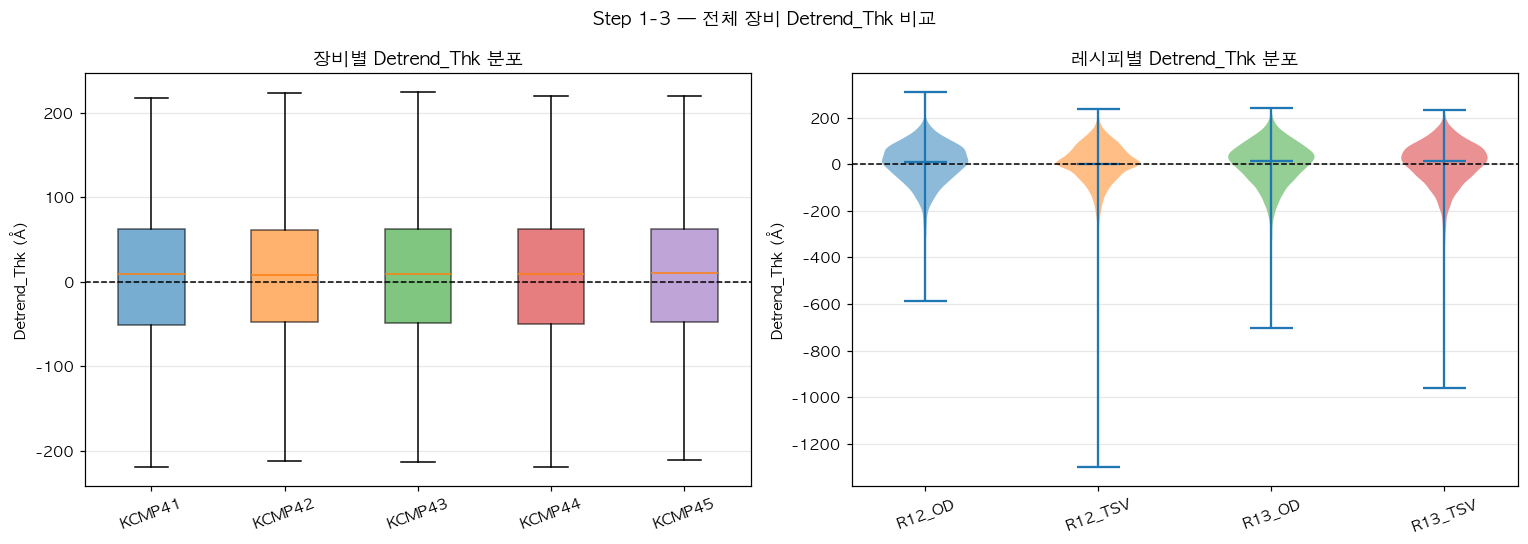

In [8]:
# ── 전체 장비 Detrend_Thk 비교 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 1-3 — 전체 장비 Detrend_Thk 비교', fontsize=12, fontweight='bold')

det_all = pre_thk_df.dropna(subset=['Detrend_Thk'])

# ① 장비별 분포 (boxplot)
ax = axes[0]
bp_data  = [det_all[det_all['eqp_id']==eq]['Detrend_Thk'].values for eq in eqp_list]
bp = ax.boxplot(bp_data, labels=eqp_list, patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('장비별 Detrend_Thk 분포')
ax.set_ylabel('Detrend_Thk (Å)')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)

# ② 레시피별 분포 (violin)
ax = axes[1]
rcp_list = sorted(det_all['recipe_id'].unique())
vp_data  = [det_all[det_all['recipe_id']==rcp]['Detrend_Thk'].values for rcp in rcp_list]
vp = ax.violinplot(vp_data, positions=range(len(rcp_list)), showmedians=True)
for body, c in zip(vp['bodies'], colors):
    body.set_facecolor(c); body.set_alpha(0.5)
ax.set_xticks(range(len(rcp_list)))
ax.set_xticklabels([r.replace('E2_M1CU_','').replace('.CAS','') for r in rcp_list], rotation=20)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('레시피별 Detrend_Thk 분포')
ax.set_ylabel('Detrend_Thk (Å)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 2 — `iqr_filter()` : 이상치 제거

```python
# PRE_THK_VM.py  iqr_filter()
q1, q3 = df[col].quantile([0.25, 0.75])
IQR    = q3 - q1
return df[(df[col] >= q1 - sigma*IQR) & (df[col] <= q3 + sigma*IQR)]
# sigma=3 : 약 99.7% 범위 보존
```

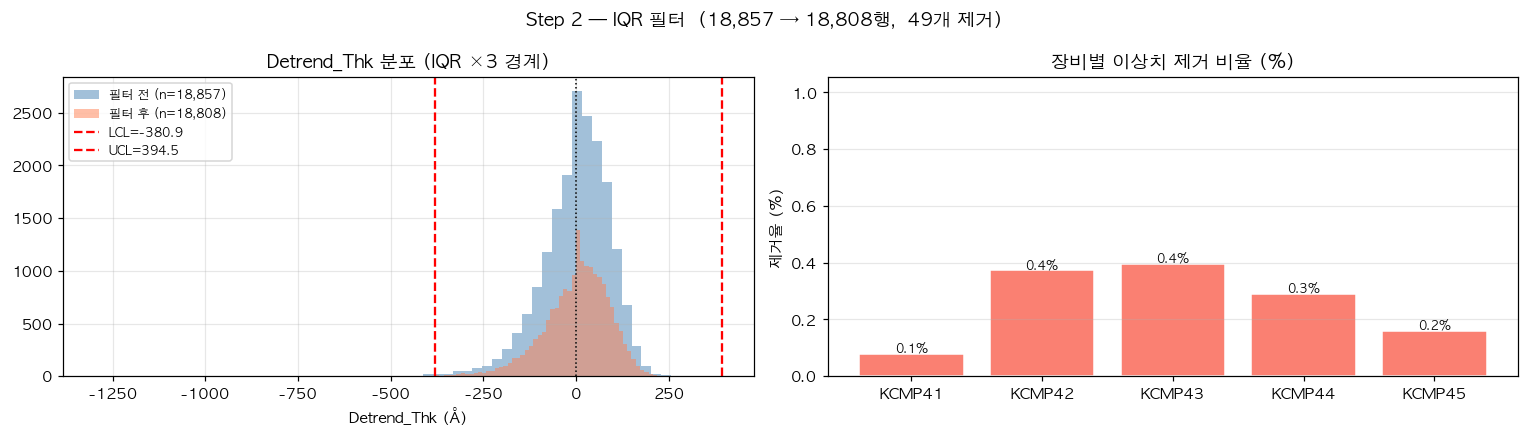

IQR 범위  Q1=-48.6, Q3=62.2, IQR=110.8
3σ IQR 경계  LCL=-380.9 ~ UCL=394.5


In [9]:
# ── PRE_THK_VM_Get.iqr_filter() 실제 함수 호출 ──────────────────────
pre_thk_df_filtered = PRE_THK_VM_Get.iqr_filter(pre_thk_df, 'Detrend_Thk')

n_before = pre_thk_df['Detrend_Thk'].notna().sum()
n_after  = len(pre_thk_df_filtered)
n_removed= n_before - n_after

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Step 2 — IQR 필터  ({n_before:,} → {n_after:,}행,  {n_removed}개 제거)', fontsize=12, fontweight='bold')

# ① 전체 분포 비교
ax = axes[0]
det_before = pre_thk_df['Detrend_Thk'].dropna()
det_after  = pre_thk_df_filtered['Detrend_Thk']
ax.hist(det_before, bins=60, alpha=0.5, color='steelblue', label=f'필터 전 (n={len(det_before):,})')
ax.hist(det_after,  bins=60, alpha=0.5, color='coral',     label=f'필터 후 (n={len(det_after):,})')

# IQR 경계 표시
q1, q3 = det_before.quantile([0.25, 0.75])
IQR = q3 - q1
lcl, ucl = q1 - 3*IQR, q3 + 3*IQR
ax.axvline(lcl, color='red',   linewidth=1.5, linestyle='--', label=f'LCL={lcl:.1f}')
ax.axvline(ucl, color='red',   linewidth=1.5, linestyle='--', label=f'UCL={ucl:.1f}')
ax.axvline(0,   color='black', linewidth=1,   linestyle=':' )
ax.set_title('Detrend_Thk 분포 (IQR ×3 경계)')
ax.set_xlabel('Detrend_Thk (Å)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ② 장비별 제거 비율
ax = axes[1]
remove_rate = []
for eqp in eqp_list:
    nb = pre_thk_df[pre_thk_df['eqp_id']==eqp]['Detrend_Thk'].notna().sum()
    na = len(pre_thk_df_filtered[pre_thk_df_filtered['eqp_id']==eqp])
    remove_rate.append((nb - na) / nb * 100 if nb > 0 else 0)
bars = ax.bar(eqp_list, remove_rate, color='salmon', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8)
ax.set_title('장비별 이상치 제거 비율 (%)')
ax.set_ylabel('제거율 (%)')
ax.set_ylim(0, max(remove_rate) * 1.4 + 0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'IQR 범위  Q1={q1:.1f}, Q3={q3:.1f}, IQR={IQR:.1f}')
print(f'3σ IQR 경계  LCL={lcl:.1f} ~ UCL={ucl:.1f}')

---
## Step 3 — `rolling_mean()` : 시간 윈도우 이동 평균 → Pre_Thk

```python
# PRE_THK_VM.py  rolling_mean()
df['pre_eq_ch'] = df['pre_eqp_id'].astype(str) + '_' + df['pre_eqp_ch'].astype(str)

for pre_eq_ch in unique:
    raw   = df[value_col, pre_oper_time]
              .rolling(window=Pre_Thk_Period, on='pre_oper_time', min_periods=min_count)
              .mean()
    count = 위와 동일하지만 .count()

df['Pre_Thk']       = raw
df['Pre_Thk_Count'] = count
```

**pre_oper_time** 기준 시간 윈도우(`3D`) 동안의 `Detrend_Thk` 이동 평균이 **Pre_Thk** 학습값입니다.

In [10]:
# ── PRE_THK_VM_Get.rolling_mean() 실제 함수 호출 ────────────────────
pre_thk_df_rolled = PRE_THK_VM_Get.rolling_mean(
    pre_thk_df_filtered,
    'Detrend_Thk',
    Pre_Thk_Period,
    min_count=10
)

print(f'rolling_mean 완료: {len(pre_thk_df_rolled):,}행')
print(f'pre_eq_ch 수: {pre_thk_df_rolled["pre_eq_ch"].nunique()}개')
print(f'Pre_Thk NaN: {pre_thk_df_rolled["Pre_Thk"].isna().sum()}건 (min_count 미달 초기 행)')

# pre_eq_ch 별 유효 행 수
valid_per_ch = pre_thk_df_rolled.dropna(subset=['Pre_Thk']).groupby('pre_eq_ch').size()
print(f'\npre_eq_ch별 유효 Pre_Thk 건수:')
print(valid_per_ch.sort_index().to_string())

rolling_mean 완료: 18,808행
pre_eq_ch 수: 16개
Pre_Thk NaN: 144건 (min_count 미달 초기 행)

pre_eq_ch별 유효 Pre_Thk 건수:
pre_eq_ch
6KTSD501_1    1147
6KTSD501_2    1140
6KTSD502_1    1222
6KTSD502_2    1122
6KTSD503_1    1089
6KTSD503_2    1142
6KTSD504_1    1255
6KTSD504_2    1241
6KTSD505_1    1172
6KTSD505_2    1163
6KTSD506_1    1267
6KTSD506_2    1117
6KTSD507_1    1033
6KTSD507_2    1232
6KTSD508_1    1162
6KTSD508_2    1160


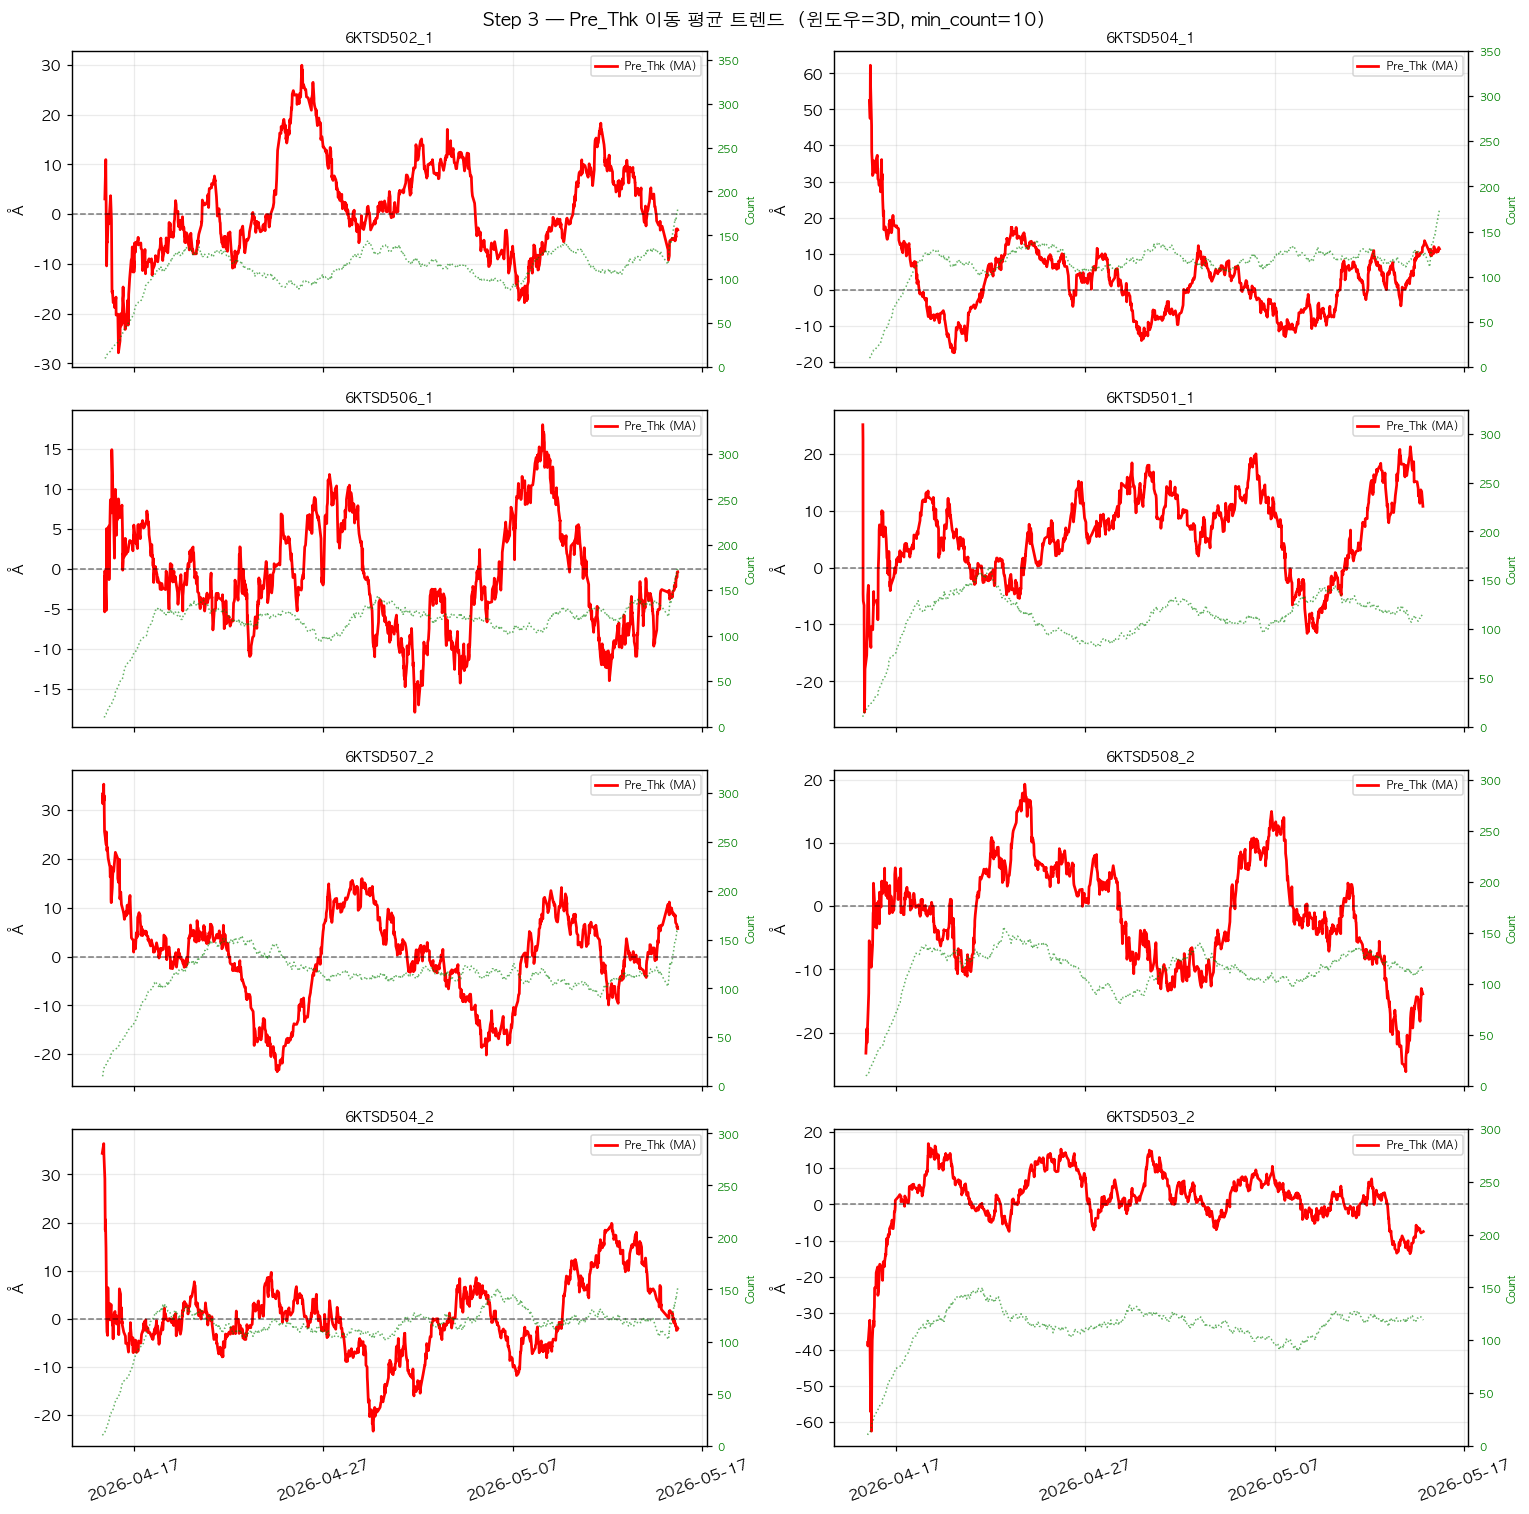

In [11]:
# ── Pre_Thk 트렌드 — pre_eq_ch 별 ────────────────────────────────────
rolled_valid = pre_thk_df_rolled.dropna(subset=['Pre_Thk'])
ch_list = sorted(rolled_valid['pre_eq_ch'].unique())

# 상위 8채널만 표시 (Count 많은 순)
top_ch = (
    rolled_valid.groupby('pre_eq_ch')['Pre_Thk_Count'].max()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
fig.suptitle(f'Step 3 — Pre_Thk 이동 평균 트렌드  (윈도우={Pre_Thk_Period}, min_count=10)', fontsize=12, fontweight='bold')
axes_flat = axes.flatten()

for ax, ch in zip(axes_flat, top_ch):
    sub = rolled_valid[rolled_valid['pre_eq_ch'] == ch].sort_values('pre_oper_time')
    raw = pre_thk_df_filtered[
        pre_thk_df_filtered.get('pre_eq_ch', pd.Series(dtype=str)).eq(ch)
        if 'pre_eq_ch' in pre_thk_df_filtered.columns
        else pd.Series([False]*len(pre_thk_df_filtered))
    ] if 'pre_eq_ch' in pre_thk_df_filtered.columns else pd.DataFrame()

    # Detrend_Thk raw scatter
    if not raw.empty:
        ax.scatter(raw['pre_oper_time'], raw['Detrend_Thk'],
                   s=4, alpha=0.25, color='steelblue', label='Detrend_Thk')

    # Pre_Thk 이동 평균 라인
    ax.plot(sub['pre_oper_time'], sub['Pre_Thk'],
            color='red', linewidth=1.8, label=f'Pre_Thk (MA)')
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

    # Count (우측 y축)
    ax2 = ax.twinx()
    ax2.plot(sub['pre_oper_time'], sub['Pre_Thk_Count'],
             color='green', linewidth=1, linestyle=':', alpha=0.6)
    ax2.set_ylabel('Count', color='green', fontsize=7)
    ax2.tick_params(axis='y', labelcolor='green', labelsize=7)
    ax2.set_ylim(0, sub['Pre_Thk_Count'].max() * 2)

    ax.set_title(f'{ch}', fontsize=9)
    ax.set_ylabel('Å')
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(alpha=0.25)

for ax in axes_flat:
    ax.tick_params(axis='x', rotation=20)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))

plt.tight_layout()
plt.show()

---
## Step 4 — `_extract_latest()` : 최신값 추출 → 최종 학습값

```python
# Common/Module.py  _extract_latest()
pre_thk_df_merge['rank'] = (
    pre_thk_df_merge.groupby('pre_eq_ch')['pre_oper_time']
    .rank(method='first', ascending=False)
)
# rank=1 인 행 (채널별 가장 최근 행) 만 추출
pre_thk_table = pre_thk_df_merge[pre_thk_df_merge['rank'] == 1]
```

In [12]:
# ── _extract_latest() 실제 함수 호출 ────────────────────────────────
pre_thk_df_rolled['THK_Para'] = Thk_Para   # Module.py 에서 설정하는 컬럼

pre_thk_table = _extract_latest(
    pre_thk_df_rolled,
    cols=['pre_oper_time', 'pre_eq_ch', 'Pre_Thk', 'Pre_Thk_Count', 'THK_Para']
)

print(f'최종 학습값: {len(pre_thk_table)}건 (pre_eq_ch 별 최신 1행)')
display(pre_thk_table.reset_index(drop=True))

최종 학습값: 16건 (pre_eq_ch 별 최신 1행)


,pre_oper_time,pre_eq_ch,Pre_Thk,Pre_Thk_Count,THK_Para
0,2026-05-14 18:35:08.552651,6KTSD505_1,1.877385,105.0,AMAT_POST_OCD_AVG
1,2026-05-14 18:35:15.932104,6KTSD506_2,12.267733,111.0,AMAT_POST_OCD_AVG
2,2026-05-14 19:39:13.362618,6KTSD508_2,-13.874361,113.0,AMAT_POST_OCD_AVG
3,2026-05-14 19:42:21.751026,6KTSD508_1,3.603075,125.0,AMAT_POST_OCD_AVG
4,2026-05-14 19:51:26.812181,6KTSD501_1,10.780029,111.0,AMAT_POST_OCD_AVG
5,2026-05-14 19:59:17.108788,6KTSD502_2,4.273649,114.0,AMAT_POST_OCD_AVG
6,2026-05-14 20:22:30.295115,6KTSD503_2,-7.492733,119.0,AMAT_POST_OCD_AVG
7,2026-05-14 20:44:15.183957,6KTSD505_2,-5.510217,133.0,AMAT_POST_OCD_AVG
8,2026-05-14 21:11:26.446030,6KTSD501_2,-1.258186,108.0,AMAT_POST_OCD_AVG
9,2026-05-14 21:49:53.605536,6KTSD503_1,-0.536422,100.0,AMAT_POST_OCD_AVG


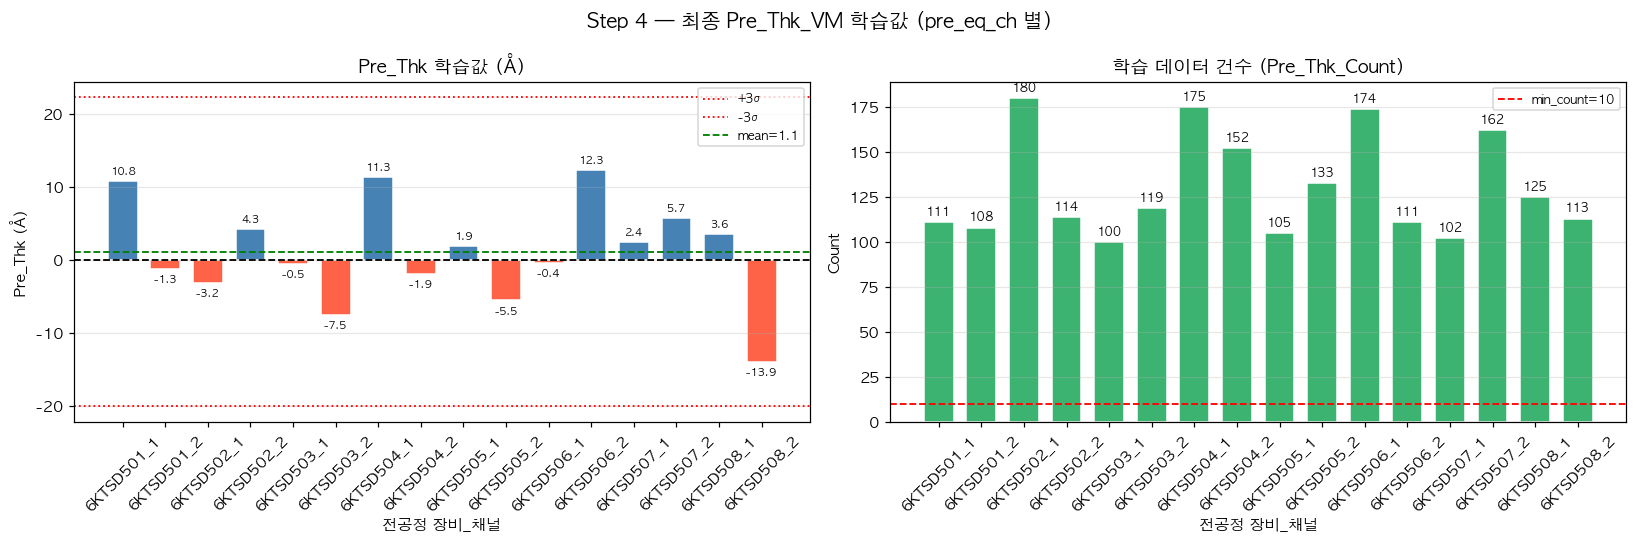

Pre_Thk 통계
  평균: 1.14 Å,  표준편차: 7.04 Å
  범위: -13.87 ~ 12.27 Å


In [13]:
# ── 최종 Pre_Thk 학습값 시각화 ───────────────────────────────────────
pre_thk_sorted = pre_thk_table.sort_values('pre_eq_ch')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Step 4 — 최종 Pre_Thk_VM 학습값 (pre_eq_ch 별)', fontsize=13, fontweight='bold')

# ① Pre_Thk — 0 기준 상하 bar
ax = axes[0]
bar_colors = ['tomato' if v < 0 else 'steelblue' for v in pre_thk_sorted['Pre_Thk']]
bars = ax.bar(pre_thk_sorted['pre_eq_ch'], pre_thk_sorted['Pre_Thk'],
              color=bar_colors, edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=3)

mean_v = pre_thk_sorted['Pre_Thk'].mean()
std_v  = pre_thk_sorted['Pre_Thk'].std()
ax.axhline(mean_v + 3*std_v, color='red',   linewidth=1.2, linestyle=':', label='+3σ')
ax.axhline(mean_v - 3*std_v, color='red',   linewidth=1.2, linestyle=':', label='-3σ')
ax.axhline(mean_v,            color='green', linewidth=1.2, linestyle='--', label=f'mean={mean_v:.1f}')

ax.set_title('Pre_Thk 학습값 (Å)')
ax.set_ylabel('Pre_Thk (Å)')
ax.set_xlabel('전공정 장비_채널')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ② Count — 학습에 사용된 데이터 건수
ax = axes[1]
bars = ax.bar(pre_thk_sorted['pre_eq_ch'], pre_thk_sorted['Pre_Thk_Count'],
              color='mediumseagreen', edgecolor='white', width=0.7)
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
ax.axhline(10, color='red', linewidth=1.2, linestyle='--', label='min_count=10')
ax.set_title('학습 데이터 건수 (Pre_Thk_Count)')
ax.set_ylabel('Count')
ax.set_xlabel('전공정 장비_채널')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Pre_Thk 통계')
print(f'  평균: {mean_v:.2f} Å,  표준편차: {std_v:.2f} Å')
print(f'  범위: {pre_thk_sorted["Pre_Thk"].min():.2f} ~ {pre_thk_sorted["Pre_Thk"].max():.2f} Å')

---
## 전체 파이프라인 한 번에

`Module_Get.compute_pre_thk_vm()` 을 호출하면 위 Step 1~4가 내부에서 모두 실행됩니다.

In [ ]:
from Common.Module import Module_Get
from Common.MongoDB_Control import _STORE
import Common.OFFSET as _offset_mod, Common.REMOVAL_RATE as _rr_mod

# load_rr_data Mock (Offset 에서 필요 — 여기선 Pre_Thk_VM만 실행하므로 불필요하지만 안전하게)
def _noop_load_rr(mdf, Fab, LC, OD, apc_list, mu, mdb):
    out = mdf.copy()
    for p in apc_list:
        out[f'{p}_B1'] = 0.80; out[f'{p}_B0'] = 5.00
    return out
_offset_mod.OFFSET_Get.load_rr_data = staticmethod(_noop_load_rr)

_STORE.clear()

key_str  = 'LC_V5077000E_M10'
mico_key = mico[mico.assign(for_key_list=
    mico['Lot_Code']+'_'+mico['Oper_Code']+'_'+mico['Fab'])['for_key_list'] == key_str].copy()
if mico_key.empty:
    mico_key = mico.copy()

merge_filtered = merge_df[merge_df['operation_id'] == mico_key['Oper_Code'].iloc[0]].copy()

print('--- compute_pre_thk_vm 실행 ---')
Module_Get.compute_pre_thk_vm(merge_filtered, mico_key, pol_type=3)

# Excel 캐시 확인
cache_file = ALGO_DIR / 'pre_thk_cache' / 'LC_M1_CU_CMP_M10.xlsx'
if cache_file.exists():
    cache_df = pd.read_excel(cache_file)
    print(f'\n✅ Excel 캐시 저장 확인: {cache_file.name}  ({len(cache_df)}행)')
    display(cache_df)